# KNN — 파밀리에 엘리프 What-if 시나리오 분석 (검단)

## 1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

## 2. 데이터 불러오기

In [2]:
# 훈련용 데이터 (기존 신도시) 및 테스트용 데이터 (검단) 경로 설정
train_folder = r"C:\Users\chaeh\Desktop\real\project"
test_folder  = r"C:\Users\chaeh\Desktop\real\project"

# 기존 신도시 데이터에서 운정, 광교, 판교만 훈련 데이터로 사용
df_all   = pd.read_csv(train_folder + r"\new_city.csv", encoding='utf-8-sig')
df_train = df_all[df_all['도시명'].isin(['운정', '광교', '판교'])].copy()

# 검단 데이터 불러오기
df_test = pd.read_csv(test_folder + r"\geomdan_merged.csv", encoding='utf-8-sig')

## 3. 전처리 — 거래금액 및 m2당가격

In [3]:
# 거래금액 쉼표 제거 후 정수 변환
df_train['거래금액(만원)'] = df_train['거래금액(만원)'].str.replace(',', '').astype(int)
df_test['거래금액(만원)']  = df_test['거래금액(만원)'].str.replace(',', '').astype(int)

# 전용면적당 가격(m2당가격) 파생변수 생성
df_train['m2당가격'] = df_train['거래금액(만원)'] / df_train['전용면적(㎡)']
df_test['m2당가격']  = df_test['거래금액(만원)']  / df_test['전용면적(㎡)']

## 4. 훈련/테스트 분할 (검단 2022년 이하 → 훈련 포함, 2023년 이상 → 테스트)

In [4]:
# 발표후경과년수 3년 미만 데이터 제거 (신도시 초기 불안정 거래 제외)
df_train = df_train[df_train['발표후경과년수'] >= 3]
df_test  = df_test[df_test['발표후경과년수'] >= 3]

# 검단 데이터 중 2022년 이하는 훈련에 포함, 2023년 이후는 테스트로 사용
df_geomdan_train = df_test[df_test['계약연도'] <= 2022].copy()
df_test          = df_test[df_test['계약연도'] >= 2023].copy()
df_train         = pd.concat([df_train, df_geomdan_train], ignore_index=True)

## 5. 이상치 제거

In [5]:
# 전용면적 33제곱미터 미만 제거
df_train = df_train[df_train['전용면적(㎡)'] >= 33]

# 발표후경과년수 3년미만 필터링
before   = len(df_train)
df_train = df_train[df_train['발표후경과년수'] >= 3]
print(f'발표후경과년수 3 미만 제거: {before - len(df_train)}개 → 남은 데이터: {len(df_train)}개')

# m2당가격 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean    = df_train['m2당가격'].mean()
std     = df_train['m2당가격'].std()
z_scores = (df_train['m2당가격'] - mean) / std
df_train = df_train[z_scores.abs() <= 2]

print(f'훈련 데이터: {len(df_train)}건')
print(f'테스트 데이터: {len(df_test)}건')

발표후경과년수 3 미만 제거: 0개 → 남은 데이터: 59664개
훈련 데이터: 55950건
테스트 데이터: 8152건


## 6. 독립변수 설정 및 표준화

In [6]:
# 독립변수 목록
features = ['건축년도', '층',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리',
            '단지별_세대수', '도시별_세대수']

# 결측치 제거
df_train = df_train.dropna(subset=features + ['m2당가격'])

# 훈련 데이터 독립변수와 타겟 분리
train_input  = df_train[features]
train_target = df_train['m2당가격']

# 표준화
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)

## 7. 최적 k 탐색

In [7]:
# k 값별로 KNN 모델 학습 및 훈련 점수 저장
train_score = []
k_list      = [3, 5, 7, 10, 15, 20, 30, 40, 50]
models      = []

for k in k_list:
    knn_k = KNeighborsRegressor(n_neighbors=k)
    knn_k.fit(train_scaled, train_target)
    train_score.append(knn_k.score(train_scaled, train_target))
    models.append(knn_k)

# 훈련 점수가 가장 높은 k 선택
best_idx   = train_score.index(max(train_score))
best_k     = k_list[best_idx]
knn_best   = models[best_idx]

## 8. 테스트 성능 확인

In [8]:
# 테스트 데이터 결측치 제거 및 표준화
df_test     = df_test.dropna(subset=features + ['m2당가격'])
test_input  = df_test[features]
test_target = df_test['m2당가격']
test_scaled = ss.transform(test_input)

# 성능 출력
print(f'최적 k: {best_k}')
print(f'훈련 R²: {knn_best.score(train_scaled, train_target):.4f}')
print(f'테스트 R²: {knn_best.score(test_scaled, test_target):.4f}')

최적 k: 5
훈련 R²: 0.9667
테스트 R²: 0.4564


## 9. 파밀리에 엘리프 기본 특성값 설정

In [9]:
# 파밀리에 엘리프 기본 특성값
엘리프_기본 = {
    '건축년도': 2027,
    '층': 10,
    '지하철호선개수': 2,
    '기차역까지의거리': 15.6213,
    '가장 가까운 지하철역까지의 거리': 1.206,
    '가장 가까운 IC와의 거리': 4.867,
    '발표후경과년수': 21,
    'CPI': 122.6,
    '계약연도': 2027,
    '서울도심거리': 26.5,
    '단지별_세대수': 669,
    '도시별_세대수': 60833
}

## 10. 시나리오 정의

In [10]:
# 층수별 목록
층수_목록 = {'저층 (3층)': 3, '중층 (10층)': 10, '고층 (20층)': 20}

# 시나리오별 특성값 (기본값에서 변경되는 항목만 덮어쓰기)
시나리오_목록 = {
    '현재': 엘리프_기본.copy(),
    '발표 후 25년': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4},
    '지하철 추가': {**엘리프_기본, '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
    '복합 시나리오': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 136.4,
                  '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
}

## 11. 층수별 × 시나리오별 예측 (84㎡)

In [11]:
면적_84 = 84.0

print(f"{'='*60}")
print(f'파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)')
print(f"{'='*60}")

# 층수별로 각 시나리오의 예측 금액 계산
층수_결과 = {}
for 층이름, 층값 in 층수_목록.items():
    층수_결과[층이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력값       = dict(값)
        입력값['층'] = 층값
        입력         = pd.DataFrame([입력값])[features]
        입력_scaled  = ss.transform(입력)
        예측_m2      = knn_best.predict(입력_scaled)[0]
        예측_금액    = int(예측_m2 * 면적_84)
        층수_결과[층이름].append(예측_금액)
        print(f'{층이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)')

파밀리에 엘리프 층수별 × 시나리오별 예측 (84㎡)
저층 (3층) | 현재: 52,148만원 (5.2억)
저층 (3층) | 발표 후 25년: 52,705만원 (5.3억)
저층 (3층) | 지하철 추가: 53,016만원 (5.3억)
저층 (3층) | 복합 시나리오: 62,072만원 (6.2억)
중층 (10층) | 현재: 51,270만원 (5.1억)
중층 (10층) | 발표 후 25년: 51,270만원 (5.1억)
중층 (10층) | 지하철 추가: 62,048만원 (6.2억)
중층 (10층) | 복합 시나리오: 62,048만원 (6.2억)
고층 (20층) | 현재: 59,447만원 (5.9억)
고층 (20층) | 발표 후 25년: 55,332만원 (5.5억)
고층 (20층) | 지하철 추가: 57,853만원 (5.8억)
고층 (20층) | 복합 시나리오: 62,954만원 (6.3억)


## 12. 층수별 시나리오 예측 막대 그래프

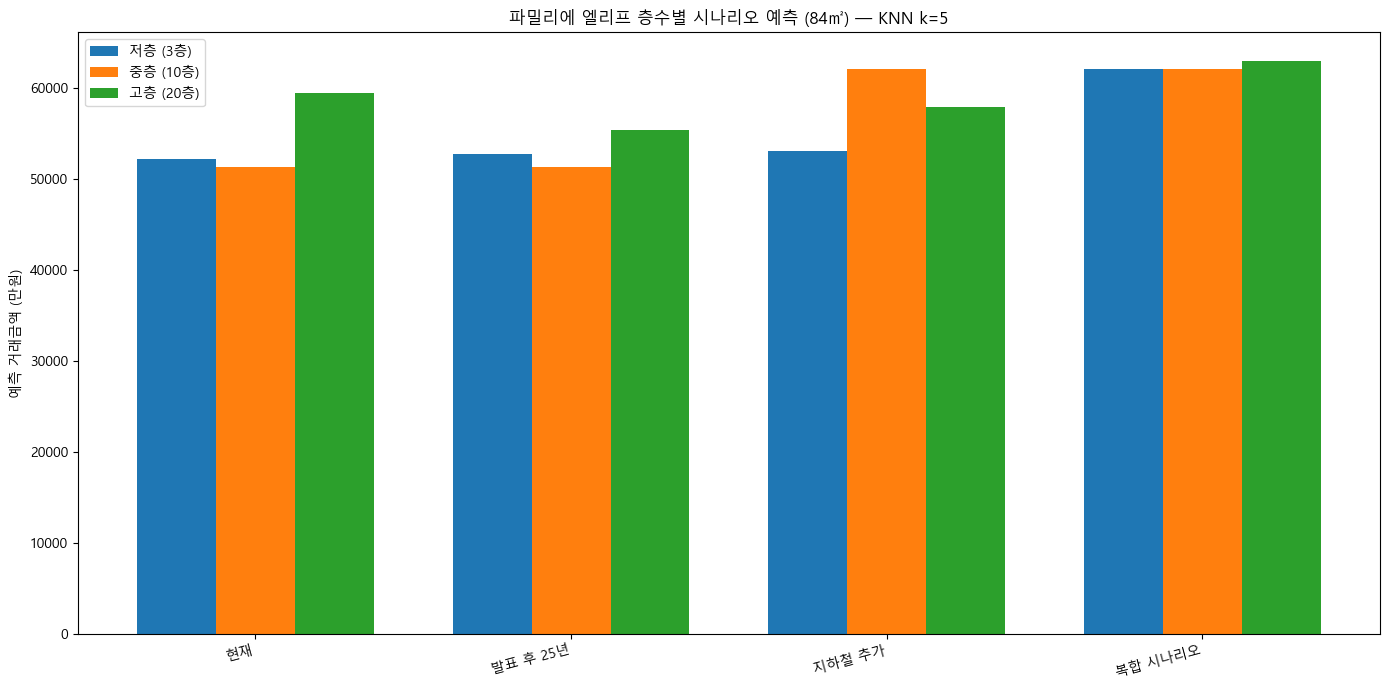

In [12]:
x     = np.arange(len(시나리오_목록))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
for i, (층이름, 값들) in enumerate(층수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=층이름)
ax.set_xticks(x + width)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title(f'파밀리에 엘리프 층수별 시나리오 예측 (84㎡) — KNN k={best_k}')
ax.legend()
plt.tight_layout()
plt.show()

## 13. 평수별 × 시나리오별 예측 (중층 10층)

In [13]:
평수_목록 = {'64㎡': 64.0, '84㎡': 84.0, '98㎡': 98.0, '110㎡': 110.0}

print(f"{'='*60}")
print(f'파밀리에 엘리프 평수별 × 시나리오별 예측 (중층 10층)')
print(f"{'='*60}")

# 평수별로 각 시나리오의 예측 금액 계산
평수_결과 = {}
for 평수이름, 면적값 in 평수_목록.items():
    평수_결과[평수이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력        = pd.DataFrame([값])[features]
        입력_scaled = ss.transform(입력)
        예측_m2     = knn_best.predict(입력_scaled)[0]
        예측_금액   = int(예측_m2 * 면적값)
        평수_결과[평수이름].append(예측_금액)
        print(f'{평수이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)')

파밀리에 엘리프 평수별 × 시나리오별 예측 (중층 10층)
64㎡ | 현재: 39,063만원 (3.9억)
64㎡ | 발표 후 25년: 39,063만원 (3.9억)
64㎡ | 지하철 추가: 47,275만원 (4.7억)
64㎡ | 복합 시나리오: 47,275만원 (4.7억)
84㎡ | 현재: 51,270만원 (5.1억)
84㎡ | 발표 후 25년: 51,270만원 (5.1억)
84㎡ | 지하철 추가: 62,048만원 (6.2억)
84㎡ | 복합 시나리오: 62,048만원 (6.2억)
98㎡ | 현재: 59,815만원 (6.0억)
98㎡ | 발표 후 25년: 59,815만원 (6.0억)
98㎡ | 지하철 추가: 72,389만원 (7.2억)
98㎡ | 복합 시나리오: 72,389만원 (7.2억)
110㎡ | 현재: 67,140만원 (6.7억)
110㎡ | 발표 후 25년: 67,140만원 (6.7억)
110㎡ | 지하철 추가: 81,253만원 (8.1억)
110㎡ | 복합 시나리오: 81,253만원 (8.1억)


## 14. 평수별 시나리오 예측 막대 그래프

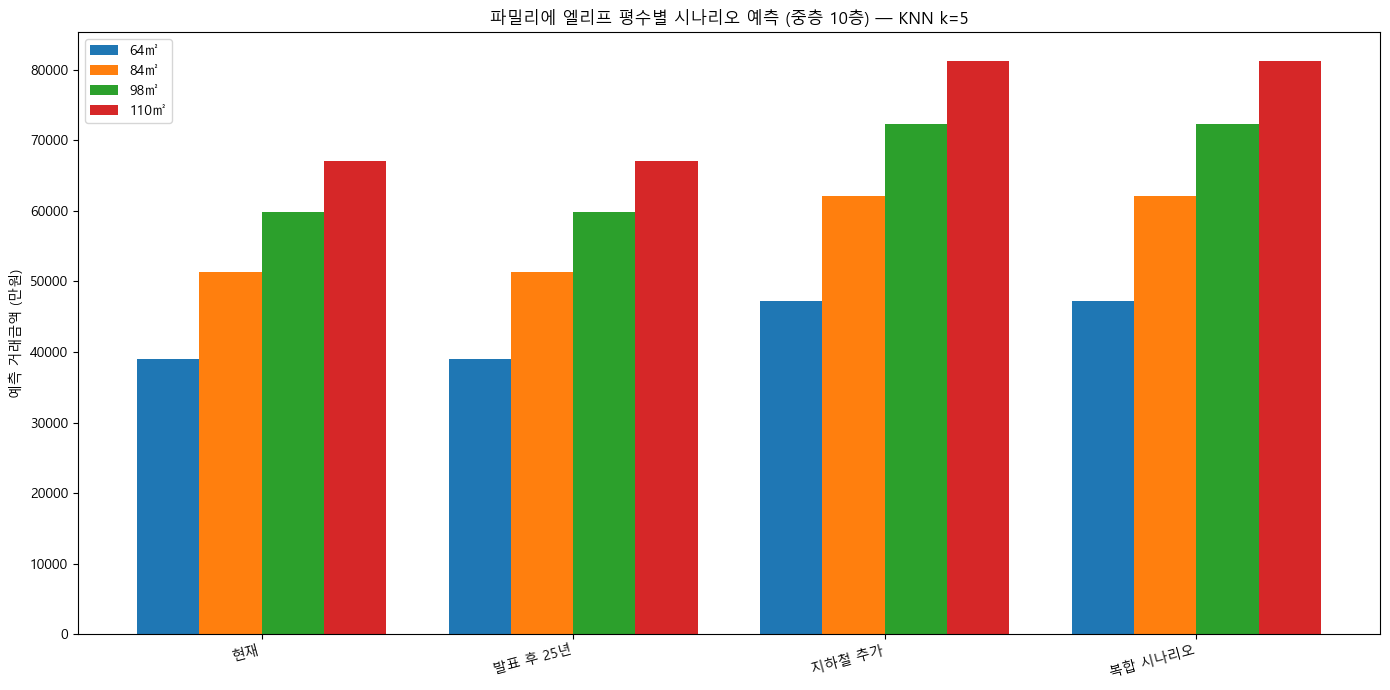

In [14]:
x     = np.arange(len(시나리오_목록))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 7))
for i, (평수이름, 값들) in enumerate(평수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=평수이름)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title(f'파밀리에 엘리프 평수별 시나리오 예측 (중층 10층) — KNN k={best_k}')
ax.legend()
plt.tight_layout()
plt.show()